# Bibliotk

In [ ]:
import re
import nltk
import random
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.svm import LinearSVC
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from imblearn.under_sampling import NearMiss
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from nltk.corpus import stopwords, wordnet as wn
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import ClusterCentroids
from sklearn.metrics import pairwise_distances_argmin_min
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

In [ ]:
# NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

# Cargamos los conjuntos

In [ ]:
df_train_EDA = pd.read_csv('/content/train_final_EDA.csv')
df_test_final = pd.read_csv('/content/test_final.csv')
df_val_final = pd.read_csv('/content/val_final.csv')

In [ ]:
df_train_EDA.shape

(80600, 2)

In [ ]:
df_train_EDA.isnull().sum()

,0
tweet,0
clase,0


/tmp/ipykernel_3535/1881380495.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_train_EDA, x='clase', palette=['#1f77b4','#d62728'])


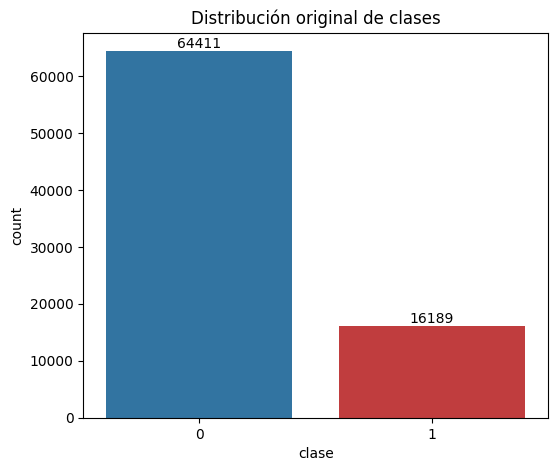

In [ ]:
plt.figure(figsize=(6,5))
ax = sns.countplot(data=df_train_EDA, x='clase', palette=['#1f77b4','#d62728'])
for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.title("Distribución original de clases")
plt.show()

In [ ]:
df_val_final.shape

(10508, 2)

In [ ]:
df_test_final.shape

(20967, 2)

In [ ]:
'''df_train_EDA["longitud"] = (df_train_EDA["tweet"].astype(str).apply(len))

plt.figure(figsize=(8,5))
sns.histplot(
    df_train_EDA["longitud"],
    bins=50,
    kde=True
)

plt.title("Distribución de longitud de textos")
plt.xlabel("Número de caracteres")
plt.ylabel("Frecuencia")
plt.show()

print(df_train_EDA["longitud"].describe())'''

'df_train_EDA["longitud"] = (df_train_EDA["tweet"].astype(str).apply(len))\n\nplt.figure(figsize=(8,5))\nsns.histplot(\n    df_train_EDA["longitud"],\n    bins=50,\n    kde=True\n)\n\nplt.title("Distribución de longitud de textos")\nplt.xlabel("Número de caracteres")\nplt.ylabel("Frecuencia")\nplt.show()\n\nprint(df_train_EDA["longitud"].describe())'

# PSC

In [ ]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=3,
    max_df=0.9
)

X_train = vectorizer.fit_transform(
    df_train_EDA['tweet'])

X_val = vectorizer.transform(
    df_val_final['tweet'])

X_test = vectorizer.transform(
    df_test_final['tweet'])

In [ ]:
y_train = df_train_EDA['clase']
y_val = df_val_final['clase']
y_test = df_test_final['clase']


In [ ]:
# Índices
x_max = np.where(y_train == 0)[0]
x_min = np.where(y_train == 1)[0]


In [ ]:
# Clase mayoritaria
X_major = X_train[x_max]

# N kluster
n_clusters = len(x_min)

# KMEANS
kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42
)

kmeans.fit(X_major)

KMeans(n_clusters=16189, random_state=42)

In [ ]:
# PROTOTIPOS

closest, _ = pairwise_distances_argmin_min(
    kmeans.cluster_centers_,
    X_major
)

# Indices select
idx_selected_major = x_max[closest]


In [ ]:
# Índices finales
idx_final = np.concatenate([
    idx_selected_major,
    x_min
])

In [ ]:
# BALANCEO

df_balanceado = df_train_EDA.iloc[
    idx_final
].copy()

df_balanceado = df_balanceado.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

# VERIFICAR
print(df_balanceado["clase"].value_counts())

print(df_balanceado.shape)

# TRAIN BALANCEADO

X_res = X_train[idx_final]
y_res = y_train.iloc[idx_final]

clase
1    16189
0    16189
Name: count, dtype: int64
(32378, 2)


In [ ]:
df_balanceado.to_csv('df_balanceado_PSC.csv', index=False)

# Clasificadores

## SVM

In [ ]:
#SVM

svm = LinearSVC(
    random_state=42
)

# ENTRENAMIENTO

svm.fit(
    X_res,
    y_res
)

LinearSVC(random_state=42)


 VALIDACIÓN SVM
              precision    recall  f1-score   support

           0       0.97      0.89      0.93      9251
           1       0.50      0.80      0.62      1257

    accuracy                           0.88     10508
   macro avg       0.74      0.85      0.77     10508
weighted avg       0.91      0.88      0.89     10508



/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
10 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/svm/_classes.py", line 321, in fit
    self.coef_, self.intercept_, n_it

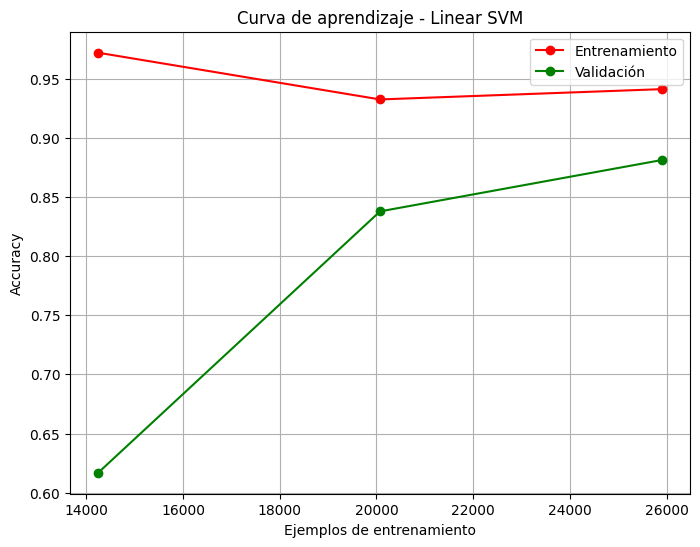

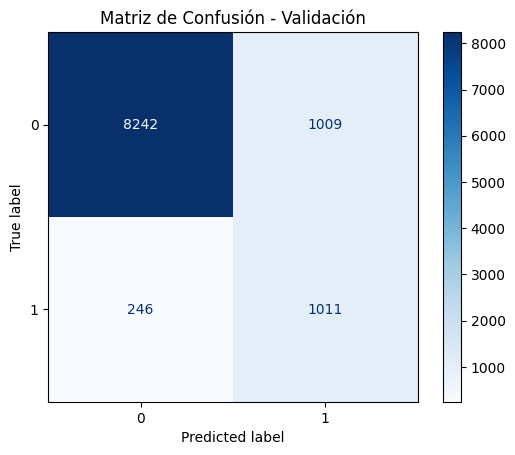

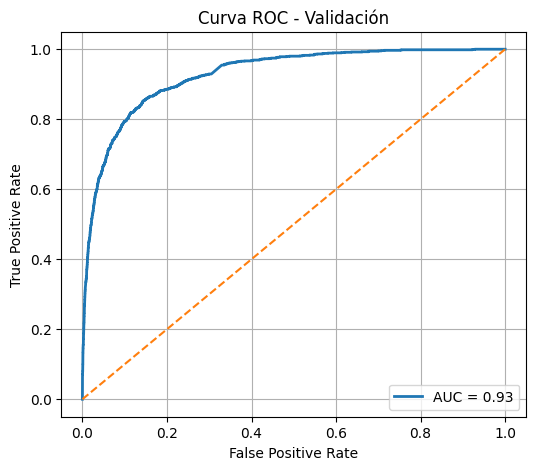

In [ ]:
# VALIDACIÓN

y_pred_val = svm.predict(
    X_val
)

print("\n VALIDACIÓN SVM")
print(
    classification_report(
        y_val,
        y_pred_val
    )
)

# CURVA DE APRENDIZAJE

train_sizes, train_scores, test_scores = learning_curve(
    svm,
    X_res,
    y_res,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(
        0.1,
        1.0,
        5
    ),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)
plt.figure(figsize=(8,6))
plt.plot(
    train_sizes,
    train_mean,
    'o-',
    color='red',
    label='Entrenamiento'
)

plt.plot(
    train_sizes,
    test_mean,
    'o-',
    color='green',
    label='Validación'
)

plt.title(
    "Curva de aprendizaje - Linear SVM"
)

plt.xlabel(
    "Ejemplos de entrenamiento"
)

plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# MATRIZ VALIDACIÓN

cm = confusion_matrix(
    y_val,
    y_pred_val
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)
disp.plot(cmap=plt.cm.Blues)
plt.title(
    "Matriz de Confusión - Validación"
)
plt.show()

# ROC VALIDACIÓN

y_score = svm.decision_function(
    X_val
)

fpr, tpr, _ = roc_curve(
    y_val,
    y_score
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f'AUC = {roc_auc:.2f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(
    "Curva ROC - Validación"
)

plt.legend(loc="lower right")
plt.grid(True)
plt.show()


 TEST FINAL SVM 
              precision    recall  f1-score   support

           0       0.98      0.89      0.93     18474
           1       0.51      0.83      0.63      2493

    accuracy                           0.89     20967
   macro avg       0.74      0.86      0.78     20967
weighted avg       0.92      0.89      0.90     20967



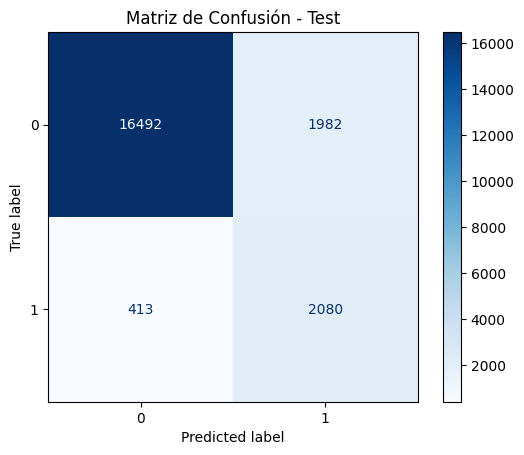

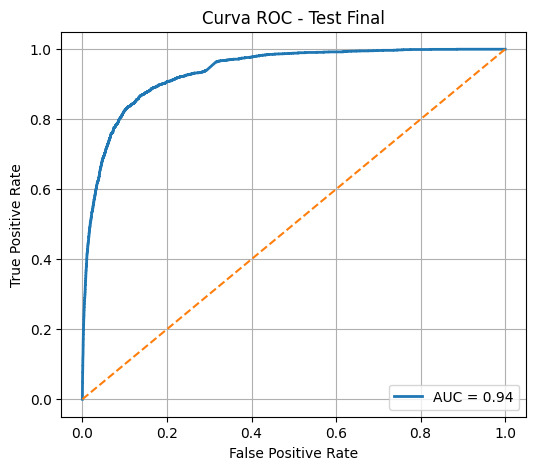

In [ ]:
# TEST FINAL

y_pred_test = svm.predict(
    X_test
)

print("\n TEST FINAL SVM ")

print(
    classification_report(
        y_test,
        y_pred_test
    )
)

# MATRIZ TEST FINAL

cm_test = confusion_matrix(
    y_test,
    y_pred_test
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test
)

disp.plot(cmap=plt.cm.Blues)

plt.title(
    "Matriz de Confusión - Test"
)

plt.show()

#ROC TEST FINAL

y_score_test = svm.decision_function(
    X_test
)

fpr, tpr, _ = roc_curve(
    y_test,
    y_score_test
)

roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f'AUC = {roc_auc:.2f}'
)
plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(
    "Curva ROC - Test Final"
)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Regresión Logistíca

In [ ]:
# REGRESIÓN LOGÍSTICA

lr = LogisticRegression(
    C=5,
    max_iter=1000,
    random_state=42
)

# ENTRENAMIENTO

lr.fit(
    X_res,
    y_res
)

LogisticRegression(C=5, max_iter=1000, random_state=42)


 VALIDACIÓN SVM
              precision    recall  f1-score   support

           0       0.97      0.90      0.93      9251
           1       0.52      0.81      0.63      1257

    accuracy                           0.89     10508
   macro avg       0.74      0.85      0.78     10508
weighted avg       0.92      0.89      0.90     10508



/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
10 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1301, in fit
    raise ValueError(
Valu

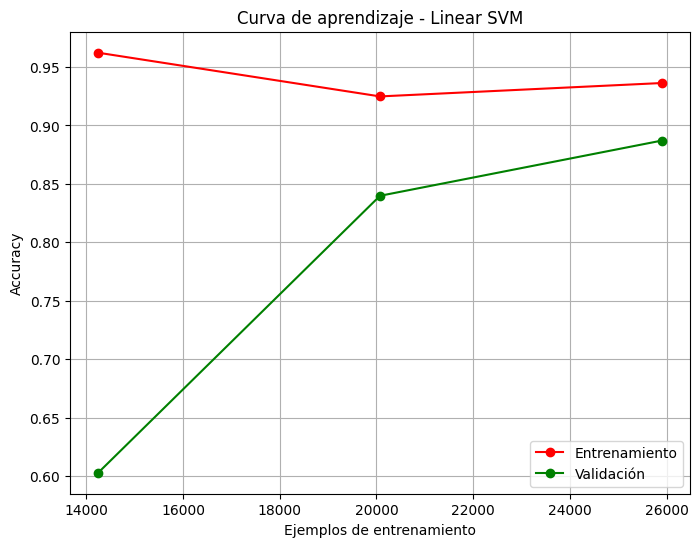

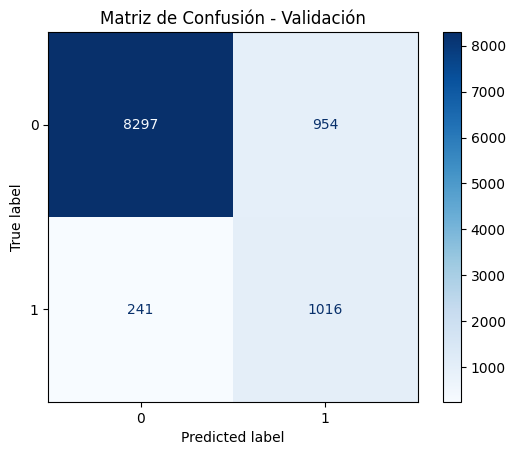

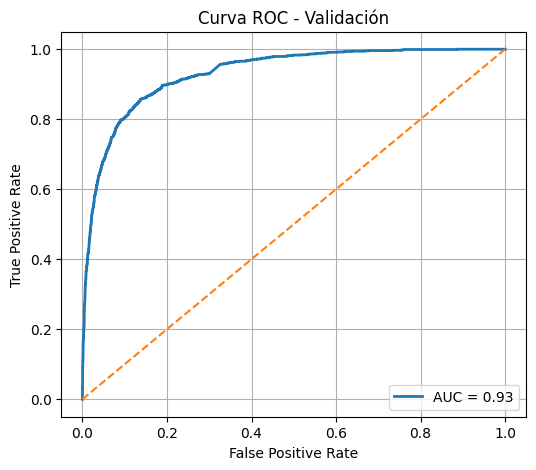

In [ ]:
# VALIDACIÓN

y_pred_val_lr = lr.predict(
    X_val
)

print("\n VALIDACIÓN SVM")
print(
    classification_report(
        y_val,
        y_pred_val_lr
    )
)

# CURVA DE APRENDIZAJE

train_sizes, train_scores, test_scores = learning_curve(
    lr,
    X_res,
    y_res,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(
        0.1,
        1.0,
        5
    ),
    n_jobs=-1
)

train_mean_lr = train_scores.mean(axis=1)
test_mean_lr = test_scores.mean(axis=1)
plt.figure(figsize=(8,6))
plt.plot(
    train_sizes,
    train_mean_lr,
    'o-',
    color='red',
    label='Entrenamiento'
)

plt.plot(
    train_sizes,
    test_mean_lr,
    'o-',
    color='green',
    label='Validación'
)

plt.title(
    "Curva de aprendizaje - Linear SVM"
)

plt.xlabel(
    "Ejemplos de entrenamiento"
)

plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# MATRIZ VALIDACIÓN

cmlr = confusion_matrix(
    y_val,
    y_pred_val_lr
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cmlr
)
disp.plot(cmap=plt.cm.Blues)
plt.title(
    "Matriz de Confusión - Validación"
)
plt.show()

# ROC VALIDACIÓN

y_score_lr = lr.decision_function(
    X_val
)

fpr, tpr, _ = roc_curve(
    y_val,
    y_score_lr
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f'AUC = {roc_auc:.2f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(
    "Curva ROC - Validación"
)

plt.legend(loc="lower right")
plt.grid(True)
plt.show()


 TEST FINAL REGRESIÓN LOGÍSTICA 
              precision    recall  f1-score   support

           0       0.98      0.90      0.93     18474
           1       0.52      0.84      0.64      2493

    accuracy                           0.89     20967
   macro avg       0.75      0.87      0.79     20967
weighted avg       0.92      0.89      0.90     20967



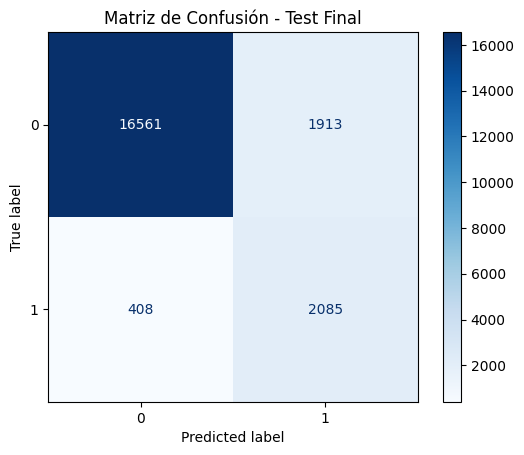

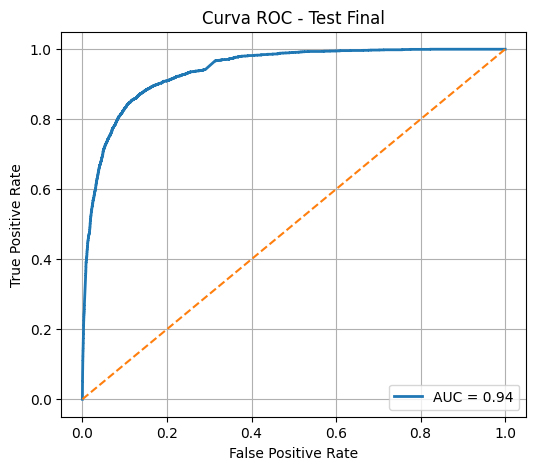

In [ ]:
#TEST FINAL

y_pred_test_lr = lr.predict(
    X_test
)

print("\n TEST FINAL REGRESIÓN LOGÍSTICA ")

print(
    classification_report(
        y_test,
        y_pred_test_lr
    )
)

# MATRIZ TEST FINAL

cm_test_lr = confusion_matrix(
    y_test,
    y_pred_test_lr
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test_lr
)

disp.plot(cmap=plt.cm.Blues)

plt.title(
    "Matriz de Confusión - Test Final"
)

plt.show()

# ROC TEST FINAL

y_score_test_lr = lr.predict_proba(
    X_test
)[:,1]

fpr, tpr, _ = roc_curve(
    y_test,
    y_score_test_lr
)

roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f'AUC = {roc_auc:.2f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(
    "Curva ROC - Test Final"
)

plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Naive Bayes

In [ ]:
# NAIVE BAYES

nb = MultinomialNB(alpha=0.01)

# ENTRENAMIENTO

nb.fit(
    X_res,
    y_res
)

MultinomialNB(alpha=0.01)


 VALIDACIÓN NAIVE BAYES 
              precision    recall  f1-score   support

           0       0.97      0.81      0.89      9251
           1       0.38      0.84      0.52      1257

    accuracy                           0.81     10508
   macro avg       0.68      0.83      0.70     10508
weighted avg       0.90      0.81      0.84     10508



/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
10 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1301, in fit
    raise ValueError(
Valu

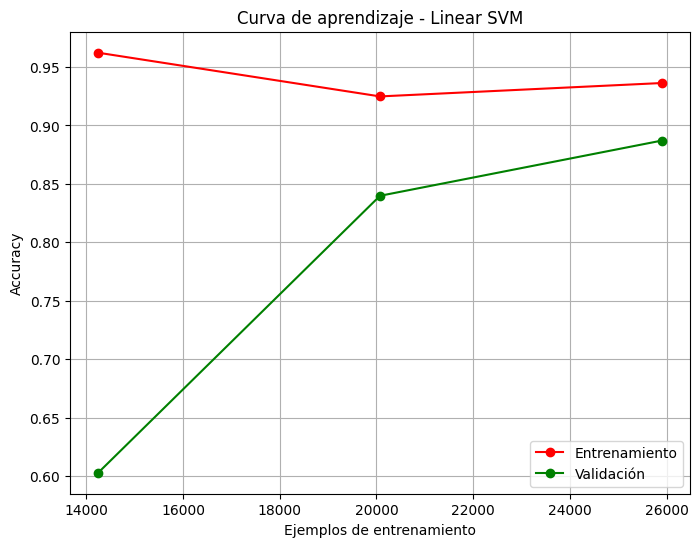

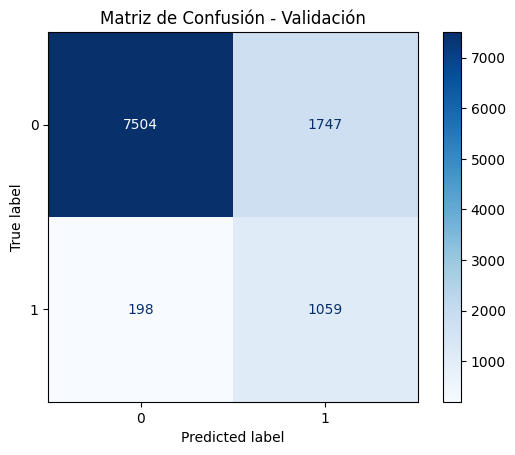

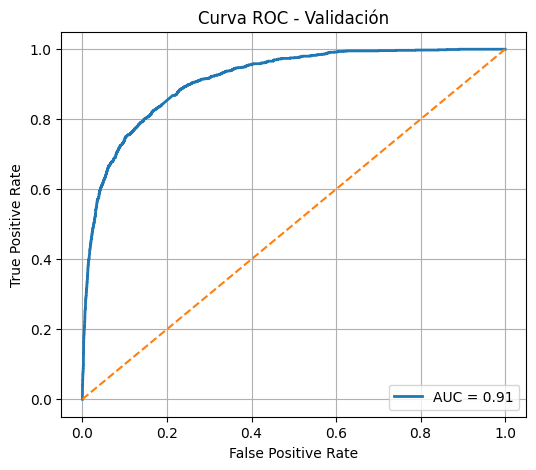

In [ ]:
# VALIDACIÓN

y_pred_val_nb = nb.predict(
    X_val
)

print("\n VALIDACIÓN NAIVE BAYES ")

print(
    classification_report(
        y_val,
        y_pred_val_nb
    )
)

# CURVA DE APRENDIZAJE

train_sizes, train_scores, test_scores = learning_curve(
    lr,
    X_res,
    y_res,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(
        0.1,
        1.0,
        5
    ),
    n_jobs=-1
)

#Curva de aprendizaje

train_mean_nb = train_scores.mean(axis=1)
test_mean_nb = test_scores.mean(axis=1)
plt.figure(figsize=(8,6))
plt.plot(
    train_sizes,
    train_mean_nb,
    'o-',
    color='red',
    label='Entrenamiento'
)

plt.plot(
    train_sizes,
    test_mean_nb,
    'o-',
    color='green',
    label='Validación'
)

plt.title(
    "Curva de aprendizaje - Linear SVM"
)

plt.xlabel(
    "Ejemplos de entrenamiento"
)

plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

#Matriz de Confusion

cm_val_nb = confusion_matrix(
    y_val,
    y_pred_val_nb
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_val_nb
)

disp.plot(cmap=plt.cm.Blues)

plt.title(
    "Matriz de Confusión - Validación"
)
plt.show()

y_score_val_nb = nb.predict_proba(
    X_val
)[:,1]

fpr, tpr, _ = roc_curve(
    y_val,
    y_score_val_nb
)

#ROC CURVE

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f'AUC = {roc_auc:.2f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(
    "Curva ROC - Validación"
)

plt.legend(loc="lower right")
plt.grid(True)
plt.show()



Naive Bayes
              precision    recall  f1-score   support

           0       0.98      0.81      0.89     18474
           1       0.39      0.88      0.54      2493

    accuracy                           0.82     20967
   macro avg       0.68      0.85      0.71     20967
weighted avg       0.91      0.82      0.85     20967



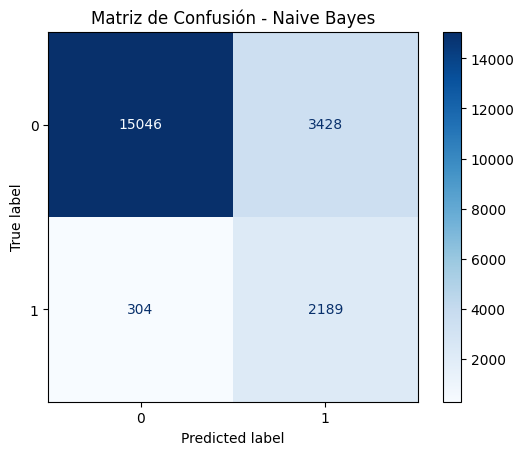

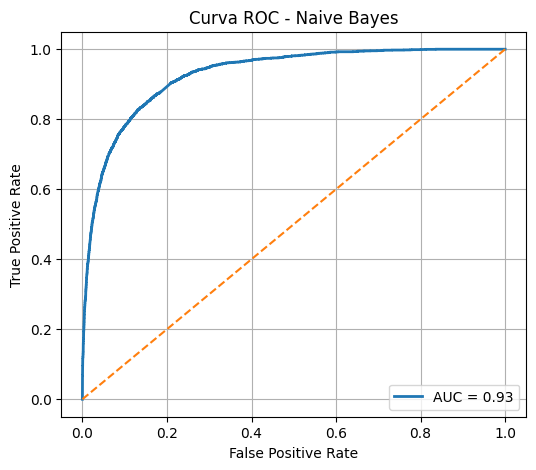

In [ ]:
# PREDICCIONES

y_pred_nb = nb.predict(
    X_test
)

print("\nNaive Bayes")
print(
    classification_report(
        y_test,
        y_pred_nb
    )
)

# MATRIZ DE CONFUSIÓN

cm = confusion_matrix(
    y_test,
    y_pred_nb
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap=plt.cm.Blues)
plt.title(
    "Matriz de Confusión - Naive Bayes"
)
plt.show()

# CURVA ROC

y_score = nb.predict_proba(
    X_test
)[:,1]

fpr, tpr, _ = roc_curve(
    y_test,
    y_score
)

roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f'AUC = {roc_auc:.2f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(
    "Curva ROC - Naive Bayes"
)

plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## MLP

In [ ]:
X_train_mlp = X_res.toarray()
X_val_mlp = X_val.toarray()
X_test_mlp = X_test.toarray()
y_train_mlp = y_res
y_val_mlp = y_val
y_test_mlp = y_test

In [ ]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size=256,
    learning_rate='adaptive',
    max_iter=40,
    random_state=42,
    verbose=True,

    # EARLY STOPPING
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15
)

# ENTRENAMIENTO

mlp.fit(
    X_train_mlp,
    y_train_mlp
)

Iteration 1, loss = 0.43214651
Validation score: 0.889438
Iteration 2, loss = 0.22395230
Validation score: 0.896541
Iteration 3, loss = 0.19185983
Validation score: 0.894070
Iteration 4, loss = 0.17076187
Validation score: 0.891909
Iteration 5, loss = 0.15063487
Validation score: 0.895615
Iteration 6, loss = 0.12834144
Validation score: 0.891600
Iteration 7, loss = 0.10591838
Validation score: 0.893144
Iteration 8, loss = 0.08516673
Validation score: 0.890056
Iteration 9, loss = 0.06927881
Validation score: 0.890673
Iteration 10, loss = 0.05728564
Validation score: 0.887894
Iteration 11, loss = 0.04897110
Validation score: 0.891291
Iteration 12, loss = 0.04294971
Validation score: 0.887276
Iteration 13, loss = 0.03896375
Validation score: 0.891291
Iteration 14, loss = 0.03650384
Validation score: 0.892526
Iteration 15, loss = 0.03440230
Validation score: 0.882952
Iteration 16, loss = 0.03315604
Validation score: 0.888820
Iteration 17, loss = 0.03244425
Validation score: 0.891600
Iterat

MLPClassifier(alpha=0.001, batch_size=256, early_stopping=True,
              hidden_layer_sizes=(128, 64), learning_rate='adaptive',
              max_iter=40, n_iter_no_change=15, random_state=42, verbose=True)


=== VALIDACIÓN MLP ===
              precision    recall  f1-score   support

           0       0.97      0.91      0.94      9251
           1       0.53      0.79      0.63      1257

    accuracy                           0.89     10508
   macro avg       0.75      0.85      0.78     10508
weighted avg       0.92      0.89      0.90     10508



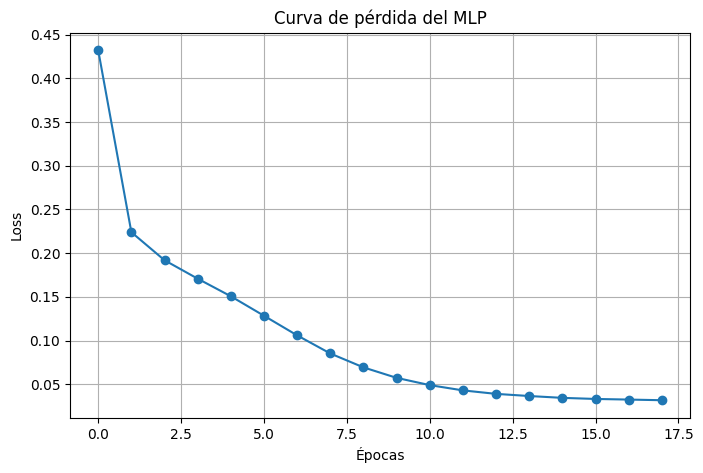

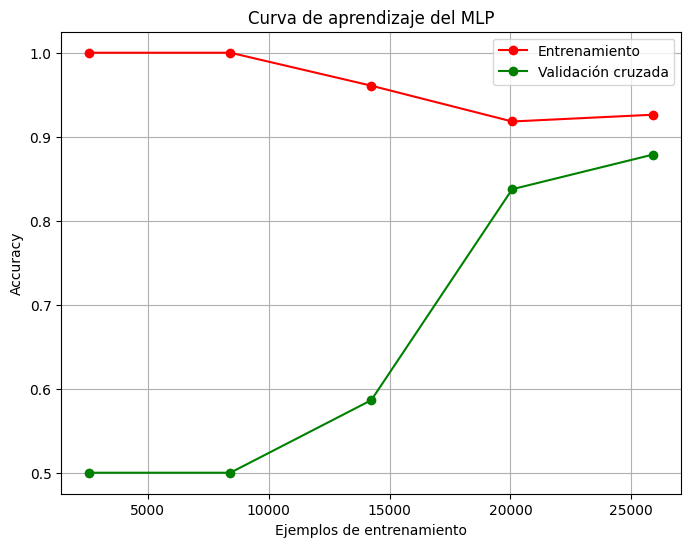

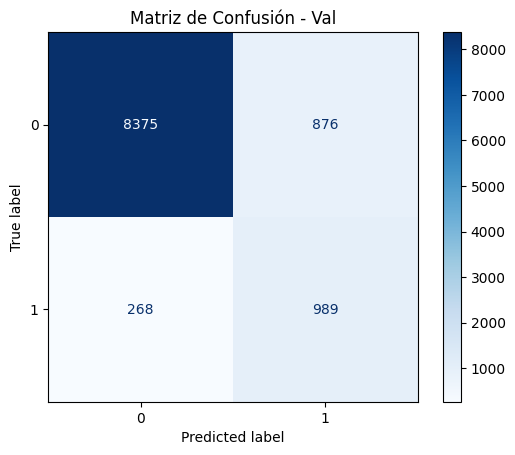

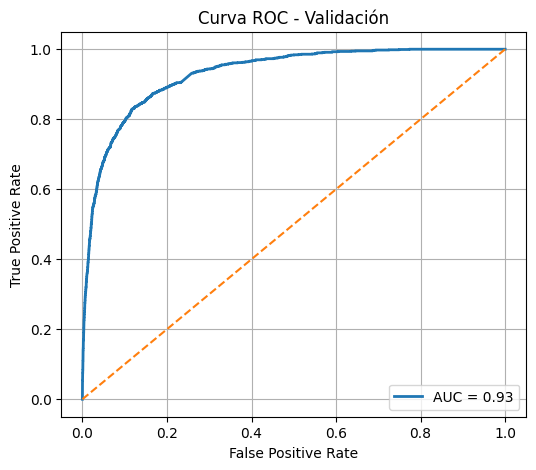

In [ ]:
# VALIDACIÓN

y_pred_val_mlp = mlp.predict(
    X_val_mlp
)

print("\n=== VALIDACIÓN MLP ===")

print(
    classification_report(
        y_val_mlp,
        y_pred_val_mlp
    )
)

# CURVA DE PÉRDIDA

plt.figure(figsize=(8,5))
plt.plot(mlp.loss_curve_, marker='o')
plt.title("Curva de pérdida del MLP")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# CURVA DE APRENDIZAJE

# CURVA DE APRENDIZAJE

train_sizes, train_scores, test_scores = learning_curve(

    mlp,
    X_train_mlp,
    y_train_mlp,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(
        0.1,
        1.0,
        5
    ),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,6))
plt.plot(
    train_sizes,
    train_mean,
    'o-',
    color='red',
    label='Entrenamiento'
)

plt.plot(
    train_sizes,
    test_mean,
    'o-',
    color='green',
    label='Validación cruzada'
)

plt.title("Curva de aprendizaje del MLP")
plt.xlabel("Ejemplos de entrenamiento")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# MATRIZ VALIDACIÓN
cm_val = confusion_matrix(
    y_val_mlp,
    y_pred_val_mlp
)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_val)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Val")
plt.show()

# ROC VALIDACIÓN
y_score_val = mlp.predict_proba(
    X_val_mlp
)[:,1]

fpr, tpr, _ = roc_curve(y_val_mlp,y_score_val)

roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f'AUC = {roc_auc:.2f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Validación")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()



TEST FINAL MLP
              precision    recall  f1-score   support

           0       0.97      0.91      0.94     18474
           1       0.54      0.81      0.65      2493

    accuracy                           0.89     20967
   macro avg       0.75      0.86      0.79     20967
weighted avg       0.92      0.89      0.90     20967



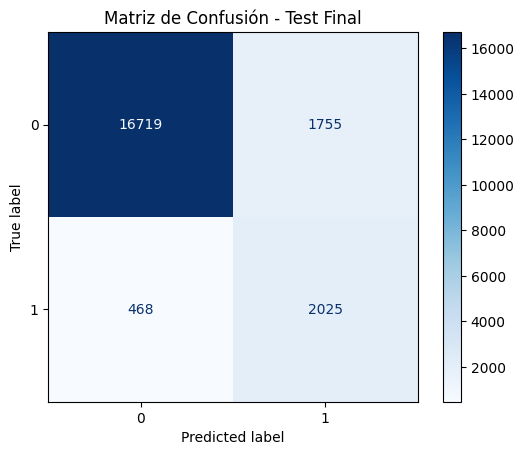

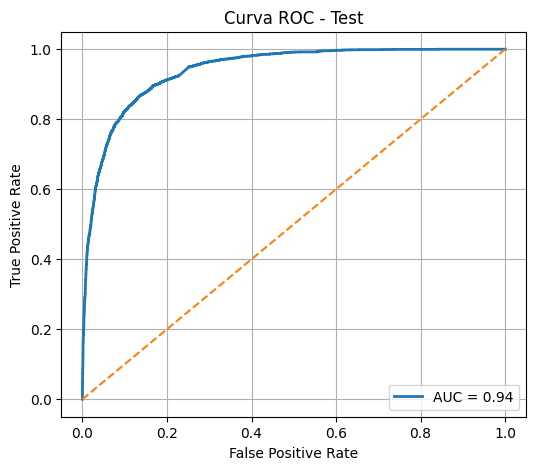

In [ ]:
# TEST FINAL
y_pred_test_mlp = mlp.predict(
    X_test_mlp
)

print("\nTEST FINAL MLP")

print(
    classification_report(
        y_test_mlp,
        y_pred_test_mlp
    )
)

# MATRIZ TEST FINAL
cm_test = confusion_matrix(
    y_test_mlp,
    y_pred_test_mlp
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test
)

disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Test Final")
plt.show()

# ROC TEST FINAL

y_score_test = mlp.predict_proba(
    X_test_mlp
)[:,1]

fpr, tpr, _ = roc_curve(
    y_test_mlp,
    y_score_test
)

roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f'AUC = {roc_auc:.2f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Test")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()